**Students:** Ana Rivera, Marcus Chen
**Section:** A
**Date:** April 27, 2026
**Responsibilities:** Ana Rivera: data cleaning (Q1), monthly score trend (Q3), written summaries. Marcus Chen: ZIP code fail rates (Q2), cuisine violations (Q4), chart formatting. Both: presentation.

# Miami-Dade Restaurant Inspections 2025 (Section A)

This notebook cleans the synthetic 2025 inspection data and answers the four Section A questions:
1. **Q1** Cleaning
2. **Q2** Fail rate by ZIP code
3. **Q3** Average score by month
4. **Q4** Violations per inspection by cuisine

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "mdc_restaurant_inspections_2025.csv"

In [2]:
inspections_raw = pd.read_csv(DATA_PATH)
print(inspections_raw.shape)
inspections_raw.head()

(2480, 8)


   inspection_id            restaurant_name  zip_code  inspection_date      cuisine    score  violations       result
0         250001          Mango Moon Bakery   33135.0       2025-01-02  Cafe/Bakery       96           0         Pass
1         250002  Pelican Pete's Fish Shack   33142.0       2025-01-02      Seafood       71           6  Conditional
2         250003       Jade Lantern Noodles   33125.0       2025-01-03      Chinese       88           2         pass
3         250004       Tia Rosa Test Cocina   33010.0       2025-01-03        Cuban  pending           3         Pass
4         250005         Bayside Burger Lab   33161.0       2025-01-06     American       64           7         Fail

## Q1. Cleaning

Before answering any question we check three things: **data types**, **missing values**, and **duplicates**.

In [3]:
inspections_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2480 entries, 0 to 2479
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   inspection_id    2480 non-null   int64
 1   restaurant_name  2480 non-null   object
 2   zip_code         2468 non-null   float64
 3   inspection_date  2480 non-null   object
 4   cuisine          2423 non-null   object
 5   score            2480 non-null   object
 6   violations       2480 non-null   int64
 7   result           2480 non-null   object
dtypes: float64(1), int64(2), object(5)
memory usage: 155.1+ KB


In [4]:
# Missing values per column and duplicated inspection IDs
print("Duplicated inspection_id:", inspections_raw["inspection_id"].duplicated().sum())
print("Non-numeric scores:", pd.to_numeric(inspections_raw["score"], errors="coerce").isna().sum())
inspections_raw.isna().sum()

Duplicated inspection_id: 36
Non-numeric scores: 41


inspection_id       0
restaurant_name     0
zip_code           12
inspection_date     0
cuisine            57
score               0
violations          0
result              0
dtype: int64

**What we found and how we handle it**

- **Duplicates (36):** the same `inspection_id` appears twice with identical values, so we keep the first copy.
- **`score` stored as text:** 41 rows contain the word `pending` instead of a number. These are re-inspections that never received a final score, so we convert `score` to a number and **drop** those rows rather than guessing a score.
- **Missing `zip_code` (12):** Q2 is about ZIP codes and we cannot place these restaurants, so we drop them. We also store ZIP codes as 5-character text because they are labels, not quantities.
- **Missing `cuisine` (57):** the score and result are still valid, so we keep these rows and label the cuisine `Unknown` instead of losing data for Q2 and Q3.
- **Inconsistent `result` labels:** values such as `pass` and `FAIL ` are standardized to `Pass`, `Conditional`, `Fail`.
- **`inspection_date`** is converted to a real date so we can group by month.

In [5]:
inspections = inspections_raw.drop_duplicates(subset="inspection_id").copy()
n_after_dupes = len(inspections)

# "pending" scores become NaN, then rows without a score or ZIP code are dropped
inspections["score"] = pd.to_numeric(inspections["score"], errors="coerce")
inspections = inspections.dropna(subset=["score", "zip_code"])

inspections["zip_code"] = inspections["zip_code"].astype(int).astype(str).str.zfill(5)
inspections["inspection_date"] = pd.to_datetime(inspections["inspection_date"])
inspections["cuisine"] = inspections["cuisine"].fillna("Unknown")
inspections["result"] = inspections["result"].str.strip().str.title()

print("Duplicates removed:", len(inspections_raw) - n_after_dupes)
print("Rows dropped (missing score or ZIP):", n_after_dupes - len(inspections))
print(f"Inspections remaining: {len(inspections):,}")
print("Result labels:", sorted(inspections["result"].unique()))

Duplicates removed: 36
Rows dropped (missing score or ZIP): 53
Inspections remaining: 2,391
Result labels: ['Conditional', 'Fail', 'Pass']


In [6]:
inspections.dtypes

inspection_id               int64
restaurant_name            object
zip_code                   object
inspection_date    datetime64[ns]
cuisine                    object
score                     float64
violations                  int64
result                     object
dtype: object

**Q1 summary.** After cleaning, **2,391 of 2,480 inspections (96.4%) remain**. The biggest hidden problem was not a blank cell but the word `pending` inside the score column: `isna()` reported zero missing scores, yet 41 scores were unusable. Dropping 89 rows is a small loss, and because the dropped rows are spread across all months and ZIP codes, we do not expect them to bias the later questions.

## Q2. Which ZIP codes have the highest fail rate?

In [7]:
# Only ZIP codes with at least 25 inspections, so one or two fails cannot dominate
zip_stats = (inspections.assign(failed=inspections["result"].eq("Fail"))
             .groupby("zip_code")["failed"].agg(inspections="size", fails="sum"))
zip_stats = zip_stats[zip_stats["inspections"] >= 25]
zip_stats["fail_rate"] = (zip_stats["fails"] / zip_stats["inspections"]).round(3)
county_fail_rate = inspections["result"].eq("Fail").mean()

top_zips = zip_stats.sort_values("fail_rate", ascending=False).head(10)
top_zips

          inspections  fails  fail_rate
zip_code                               
33142              87     16      0.184
33127              76     13      0.171
33147              92     15      0.163
33150              57      9      0.158
33010             101     15      0.149
33125             127     18      0.142
33135             110     15      0.136
33161              70      9      0.129
33054              48      6      0.125
33012             144     17      0.118

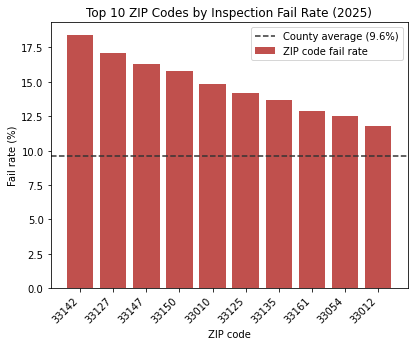

In [8]:
fig, ax = plt.subplots()
ax.bar(top_zips.index, top_zips["fail_rate"] * 100, color="#c0504d", label="ZIP code fail rate")
ax.axhline(county_fail_rate * 100, color="#333333", linestyle="--",
           label=f"County average ({county_fail_rate:.1%})")
ax.set_title("Top 10 ZIP Codes by Inspection Fail Rate (2025)")
ax.set_xlabel("ZIP code")
ax.set_ylabel("Fail rate (%)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.show()

**Q2 summary.** ZIP code **33142 has the highest fail rate (18.4%)**, almost **double the county average of 9.6%**, followed by 33127 and 33147. Seven of the top ten ZIP codes are clustered north and west of downtown, which suggests the problem is regional rather than a few bad restaurants. We required at least 25 inspections per ZIP code because, without that filter, a ZIP code with 3 inspections and 1 fail would show a misleading 33% fail rate.

## Q3. How does the average score change month by month?

In [9]:
monthly_score = inspections.groupby(inspections["inspection_date"].dt.month)["score"].mean().round(2)
monthly_score

inspection_date
1     86.20
2     85.90
3     85.10
4     84.60
5     83.40
6     82.10
7     80.80
8     80.30
9     81.00
10    82.70
11    84.00
12    85.30
Name: score, dtype: float64

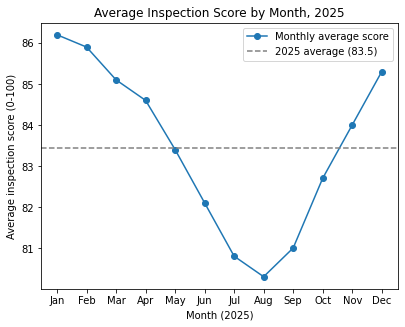

In [10]:
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots()
ax.plot(month_names, monthly_score.values, marker="o", label="Monthly average score")
ax.axhline(monthly_score.mean(), color="gray", linestyle="--",
           label=f"2025 average ({monthly_score.mean():.1f})")
ax.set_title("Average Inspection Score by Month, 2025")
ax.set_xlabel("Month (2025)")
ax.set_ylabel("Average inspection score (0-100)")
ax.legend()
plt.show()

**Q3 summary.** Average scores fall steadily from **86.2 in January to a low of 80.3 in August**, then recover to 85.3 by December. The dip lines up with the hottest and most humid months, when keeping food at safe temperatures is hardest, so we think summer conditions (not stricter inspectors) explain most of the drop. A practical takeaway is that extra inspections or reminders in June through September could have the largest effect.

## Q4. Which cuisines have the most violations per inspection?

In [11]:
cuisine_violations = (inspections.groupby("cuisine")["violations"]
                      .agg(inspections="size", total_violations="sum"))
cuisine_violations["violations_per_inspection"] = (
    cuisine_violations["total_violations"] / cuisine_violations["inspections"]).round(2)
cuisine_violations = cuisine_violations.sort_values("violations_per_inspection", ascending=False)
cuisine_violations

             inspections  total_violations  violations_per_inspection
cuisine                                                              
Seafood              212              1018                       4.80
Chinese              241              1085                       4.50
Haitian              176               722                       4.10
Cuban                398              1552                       3.90
Mexican              187               692                       3.70
Peruvian             129               439                       3.40
American             356              1139                       3.20
Italian              203               609                       3.00
Unknown               55               165                       3.00
Cafe/Bakery          434              1042                       2.40

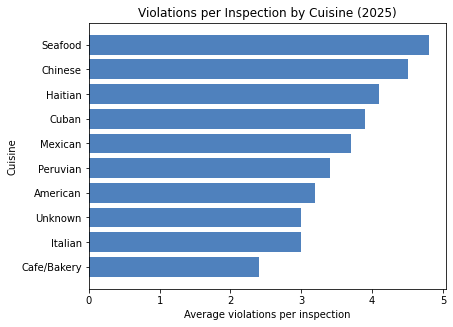

In [12]:
fig, ax = plt.subplots()
cuisine_sorted = cuisine_violations.sort_values("violations_per_inspection")
ax.barh(cuisine_sorted.index, cuisine_sorted["violations_per_inspection"], color="#4f81bd")
ax.set_title("Violations per Inspection by Cuisine (2025)")
ax.set_xlabel("Average violations per inspection")
ax.set_ylabel("Cuisine")
plt.show()

**Q4 summary.** **Seafood (4.80) and Chinese (4.50)** restaurants average the most violations per inspection, about **twice the rate of cafes and bakeries (2.40)**. Both top cuisines handle raw proteins that need strict temperature control, which connects to the summer dip we saw in Q3. Cuban restaurants are the most inspected group (398 inspections) and sit in the middle (3.90), so a high number of inspections does not by itself mean more violations. We kept the `Unknown` group in the table so readers can see it behaves like the average.

In [13]:
tmp = inspections.groupby("restaurant_name")["score"].min()

## Conclusions

- Food safety problems are concentrated **in place** (a cluster of northern ZIP codes), **in time** (June to September), and **by cuisine** (seafood and Chinese).
- If inspectors had limited time, summer visits to high-violation cuisines in the top ZIP codes would likely find the most issues.
- Limitation: the data is one year only, so we cannot tell whether the summer dip repeats every year.